<a href="https://colab.research.google.com/github/Trickwillfrit/EPFL_Rolex/blob/main/notebooks/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)

In this notebook, we explore the data used for the university library recommendation system.

Our goals are:
- understand the structure of the datasets
- measure the size of the data
- inspect users, items, and interactions
- detect missing values or inconsistencies
- study the distribution of user activity and item popularity
- understand whether the metadata can help recommendation models
- prepare insights for user-user CF, item-item CF, and content-based methods

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

BASE_URL = "https://raw.githubusercontent.com/Trickwillfrit/EPFL_Rolex/main/"

interactions = pd.read_csv(BASE_URL + "interactions_train.csv")
items = pd.read_csv(BASE_URL + "items.csv")
submission = pd.read_csv(BASE_URL + "sample_submission.csv")

In [3]:
# check
print("Interactions shape:", interactions.shape)
print("Items shape:", items.shape)
print("Submission shape:", submission.shape)

Interactions shape: (87047, 3)
Items shape: (15291, 6)
Submission shape: (7838, 2)


In [4]:
display(interactions.head())
display(items.head())
display(submission.head())

,u,i,t
0,4456,8581,1.687541e+09
1,142,1964,1.679585e+09
2,362,3705,1.706872e+09
3,1809,11317,1.673533e+09
4,4384,1323,1.681402e+09


,Title,Author,ISBN Valid,Publisher,Subjects,i
0,Classification décimale universelle : édition ...,NaN,9782871303336; 2871303339,Ed du CEFAL,Classification décimale universelle; Indexatio...,0
1,Les interactions dans l'enseignement des langu...,"Cicurel, Francine, 1947-",9782278058327; 2278058320,Didier,didactique--langue étrangère - enseignement; d...,1
2,Histoire de vie et recherche biographique : pe...,NaN,2343190194; 9782343190198,L'Harmattan,Histoires de vie en sociologie; Sciences socia...,2
3,Ce livre devrait me permettre de résoudre le c...,"Mazas, Sylvain, 1980-",9782365350020; 236535002X; 9782365350488; 2365...,Vraoum!,Moyen-Orient; Bandes dessinées autobiographiqu...,3
4,Les années glorieuses : roman /,"Lemaitre, Pierre, 1951-",9782702180815; 2702180817; 9782702183618; 2702...,Calmann-Lévy,France--1945-1975; Roman historique; Roman fra...,4


,user_id,recommendation
0,0,3758 11248 9088 9895 5101 6074 9295 14050 1096...
1,1,3263 726 1589 14911 6432 10897 6484 7961 8249 ...
2,2,13508 9848 12244 2742 11120 2893 2461 5439 116...
3,3,2821 10734 6357 5934 2085 12608 12539 10551 10...
4,4,12425 219 11602 1487 14178 489 13888 2110 4413...


In [5]:
# Print the column names of each dataframe
# This helps us confirm the exact schema of each dataset
print("Interactions columns:", interactions.columns.tolist())
print("Items columns:", items.columns.tolist())
print("Submission columns:", submission.columns.tolist())

Interactions columns: ['u', 'i', 't']
Items columns: ['Title', 'Author', 'ISBN Valid', 'Publisher', 'Subjects', 'i']
Submission columns: ['user_id', 'recommendation']


In [6]:
# Display a summary of the interactions dataframe:
# column names, number of non-missing values, and data types
print("INTERACTIONS")
interactions.info()

print("\n" + "-"*50 + "\n")

# Display the same summary for the items dataframe
print("ITEMS")
items.info()

print("\n" + "-"*50 + "\n")

# Display the same summary for the submission dataframe
print("SUBMISSION")
submission.info()

INTERACTIONS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87047 entries, 0 to 87046
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   u       87047 non-null  int64  
 1   i       87047 non-null  int64  
 2   t       87047 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 2.0 MB

--------------------------------------------------

ITEMS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15291 entries, 0 to 15290
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       15291 non-null  object
 1   Author      12638 non-null  object
 2   ISBN Valid  14568 non-null  object
 3   Publisher   15266 non-null  object
 4   Subjects    13068 non-null  object
 5   i           15291 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 716.9+ KB

--------------------------------------------------

SUBMISSION
<class 'pandas.core.frame.DataFrame'>
Ran

In [7]:
# Count the total number of interactions
n_interactions = len(interactions)

# Count the number of unique users in the interactions table
n_users = interactions["u"].nunique()

# Count the number of unique items that appear in interactions
n_items_interacted = interactions["i"].nunique()

# Count the number of unique items in the metadata table
n_items_metadata = items["i"].nunique()

# Count the number of unique users in the submission file
n_users_submission = submission["user_id"].nunique()

# Print the main dataset sizes
print("Number of interactions:", n_interactions)
print("Number of unique users:", n_users)
print("Number of unique interacted items:", n_items_interacted)
print("Number of unique items in metadata:", n_items_metadata)
print("Number of unique users in submission:", n_users_submission)

Number of interactions: 87047
Number of unique users: 7838
Number of unique interacted items: 15109
Number of unique items in metadata: 15291
Number of unique users in submission: 7838


## What these numbers mean

- **87,047 interactions** means the training file contains 87,047 user-book events. Each row corresponds to one interaction between one user and one book at a given time.
- **7,838 users** means there are 7,838 distinct users in the training data.
- **15,109 interacted items** means 15,109 different books appear at least once in the interaction history.
- **15,291 items in metadata** means the catalog contains slightly more books than those seen in interactions, so some books have metadata but no recorded interaction.
- **7,838 users in submission** means we must generate recommendations for 7,838 users, and this matches the users present in the training set.

Overall, this suggests that all target users are already known, which is good for collaborative filtering, while a small number of books may require metadata-based methods because they have no interaction history.

In [8]:
# Create sets of unique user and item IDs from each dataset
users_in_train = set(interactions["u"])
users_in_submission = set(submission["user_id"])
items_in_train = set(interactions["i"])
items_in_metadata = set(items["i"])

# Find users that appear in the submission file but not in the training data
missing_users = users_in_submission - users_in_train

# Find items that appear in the metadata file but never appear in the interactions
items_without_interactions = items_in_metadata - items_in_train

# Print the number of missing users and unseen items
print("Number of submission users not in training data:", len(missing_users))
print("Number of items in metadata but not in interactions:", len(items_without_interactions))

Number of submission users not in training data: 0
Number of items in metadata but not in interactions: 182


## Consistency between the datasets

All users in the submission file are already present in the training interactions, which means we do not face a user cold-start problem at prediction time.

However, 182 books appear in the metadata file but never in the interaction history. These items have no behavioral signal, so collaborative filtering alone may not handle them well. This is one reason why metadata-based approaches can be useful.

In [9]:
# Count exact duplicate rows in the interactions table
exact_duplicates = interactions.duplicated().sum()

# Count the number of unique (user, item) pairs
unique_user_item_pairs = interactions[["u", "i"]].drop_duplicates().shape[0]

# Compare with the total number of interactions
repeated_user_item_interactions = len(interactions) - unique_user_item_pairs

# Print the results
print("Number of exact duplicate rows:", exact_duplicates)
print("Number of unique user-item pairs:", unique_user_item_pairs)
print("Number of repeated user-item interactions:", repeated_user_item_interactions)

Number of exact duplicate rows: 2
Number of unique user-item pairs: 64003
Number of repeated user-item interactions: 23044


## Repeated interactions

There are only 2 exact duplicate rows, so the dataset is mostly clean.

However, the number of total interactions is much larger than the number of unique user-item pairs. This means that many users interacted with the same book more than once.

These repeated interactions may be informative, because they can reflect stronger interest, repeated borrowing, or renewals. This is useful to keep in mind when designing recommendation models.

In [10]:
# Convert the timestamp column into a readable datetime format
interactions["datetime"] = pd.to_datetime(interactions["t"], unit="s")

# Show the first rows with the new datetime column
display(interactions[["u", "i", "t", "datetime"]].head())

,u,i,t,datetime
0,4456,8581,1.687541e+09,2023-06-23 17:24:46
1,142,1964,1.679585e+09,2023-03-23 15:30:06
2,362,3705,1.706872e+09,2024-02-02 11:00:59
3,1809,11317,1.673533e+09,2023-01-12 14:19:22
4,4384,1323,1.681402e+09,2023-04-13 16:09:22


## Converting timestamps into readable dates

In the interactions dataset, the column `t` stores time as a **Unix timestamp**, meaning the number of seconds since 1 January 1970.

To make the time information easier to interpret, we create a new column called `datetime` using `pd.to_datetime(interactions["t"], unit="s")`.

We keep the original `t` column unchanged and add `datetime` as a readable version of the same information. This allows us to analyze the interaction timeline more easily in the following steps.

## Why we interpret `t` as a Unix timestamp

The values in the column `t` are large numeric values around 1.68–1.70 billion. This is a typical scale for Unix timestamps stored in seconds.

When we convert them with `pd.to_datetime(interactions["t"], unit="s")`, we obtain realistic dates around 2023–2024, which matches the context of the dataset. For this reason, we interpret `t` as a Unix timestamp.

In [11]:
# Print the earliest and latest interaction dates in the dataset
print("First interaction date:", interactions["datetime"].min())
print("Last interaction date:", interactions["datetime"].max())

First interaction date: 2023-01-02 12:47:23
Last interaction date: 2024-10-14 16:57:34


## Time coverage of the interactions

After converting the timestamps, we can see that the interaction history goes from **2023-01-02** to **2024-10-14**.

This means the dataset covers almost two years of activity. This is important because recommendation behavior may vary over time, and it suggests that temporal patterns could matter in the analysis.

In [12]:
# Create a new column containing only the year and month of each interaction
interactions["year_month"] = interactions["datetime"].dt.to_period("M")

# Count how many interactions happened in each month
monthly_interactions = interactions["year_month"].value_counts().sort_index()

# Display the monthly counts
display(monthly_interactions)

,count
year_month,
2023-01,5466
2023-02,5532
2023-03,5927
2023-04,4345
2023-05,4989
2023-06,5249
2023-07,3495
2023-08,3852
2023-09,5065


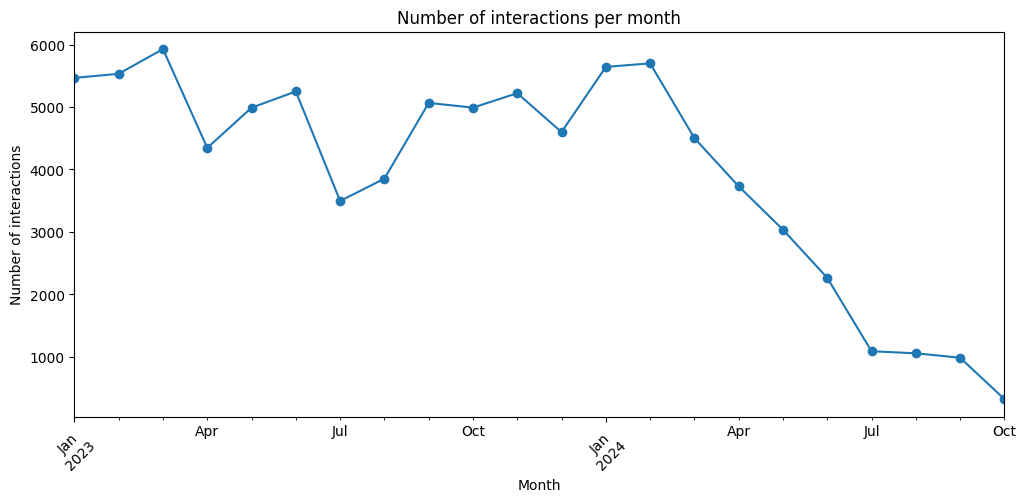

In [13]:
# Plot the number of interactions per month
monthly_interactions.plot(figsize=(12, 5), marker="o")

# Add a title and axis labels
plt.title("Number of interactions per month")
plt.xlabel("Month")
plt.ylabel("Number of interactions")

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Show the plot
plt.show()

## Monthly evolution of interactions

The number of interactions is relatively high and stable during most of 2023 and early 2024, usually around 4,500 to 6,000 interactions per month.

From spring 2024 onward, the number of interactions decreases sharply, especially during summer and early autumn. This may reflect seasonal effects, academic calendar patterns, or incomplete recent data.

This shows that user activity is not constant over time, so temporal effects may matter in the recommendation task.

In [14]:
# Count how many interactions each user has
user_activity = interactions["u"].value_counts()

# Display summary statistics for user activity
print(user_activity.describe())

count    7838.000000
mean       11.105767
std        16.441875
min         3.000000
25%         3.000000
50%         6.000000
75%        11.000000
max       385.000000
Name: count, dtype: float64


## User activity distribution

User activity is highly uneven. Although the average number of interactions per user is about 11, the median is only 6, and 25% of users have just 3 interactions.

This means that many users have a short interaction history, while a few users are much more active. This is important for recommendation because methods based on user similarity may be less reliable for users with very few interactions.

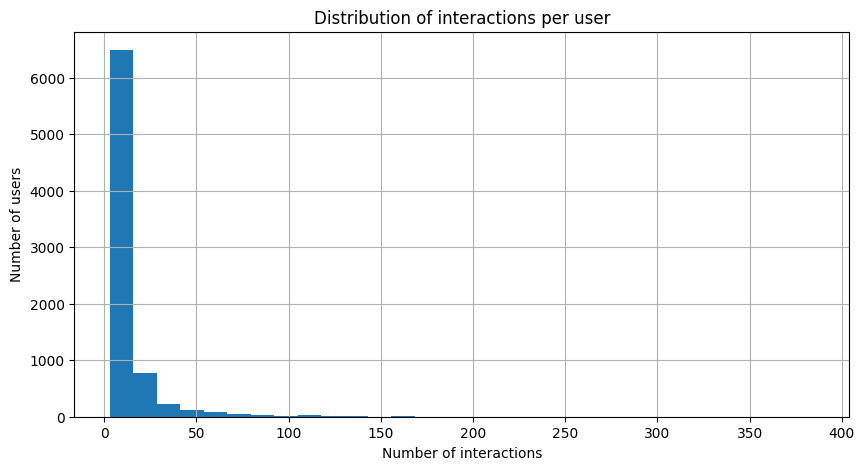

In [15]:
# Plot the distribution of the number of interactions per user
user_activity.hist(bins=30, figsize=(10, 5))

# Add a title and axis labels
plt.title("Distribution of interactions per user")
plt.xlabel("Number of interactions")
plt.ylabel("Number of users")

# Show the plot
plt.show()

## Histogram of user activity

The histogram shows that most users have only a small number of interactions, while a small minority of users are much more active.

This creates a long right tail in the distribution, with a few users having very large interaction histories. Such imbalance is common in recommendation datasets and can make user-based methods less robust for low-activity users.

In [16]:
# Count how many interactions each item has
item_popularity = interactions["i"].value_counts()

# Display summary statistics for item popularity
print(item_popularity.describe())

count    15109.000000
mean         5.761268
std          9.004874
min          1.000000
25%          3.000000
50%          4.000000
75%          6.000000
max        380.000000
Name: count, dtype: float64


## Item popularity distribution

Item popularity is also highly uneven. The average number of interactions per item is about 5.8, but the median is only 4, and some items appear only once.

This means that many books are rarely interacted with, while a small number of books are very popular. This long-tail structure is typical in recommendation datasets and suggests that popularity effects may be strong.

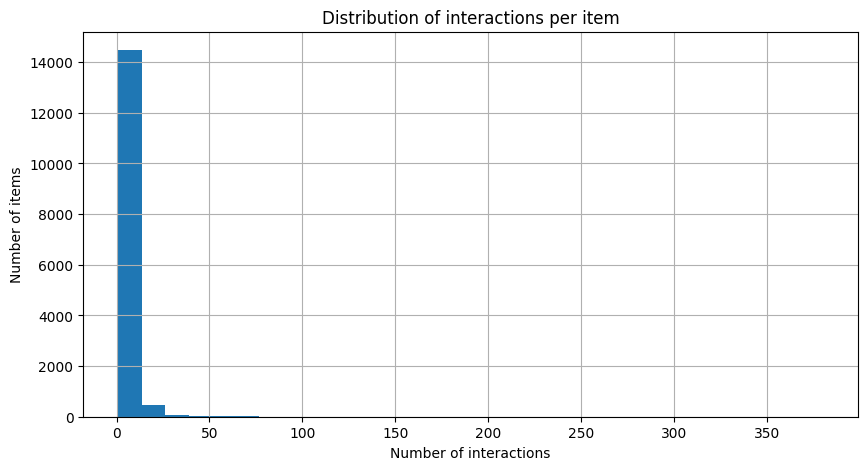

In [17]:
# Plot the distribution of the number of interactions per item
item_popularity.hist(bins=30, figsize=(10, 5))

# Add a title and axis labels
plt.title("Distribution of interactions per item")
plt.xlabel("Number of interactions")
plt.ylabel("Number of items")

# Show the plot
plt.show()

## Histogram of item popularity

The histogram shows that most books have only a small number of interactions, while a few books are much more popular than the rest.

This confirms a long-tail distribution on the item side: many books are rarely borrowed, and only a small minority concentrate a large share of the interactions. This is an important characteristic of recommendation datasets.

In [18]:
# Compute the total number of possible user-item pairs
total_possible_pairs = n_users * n_items_metadata

# Use the number of unique user-item pairs as the number of observed pairs
observed_pairs = unique_user_item_pairs

# Compute the density of the matrix
density = observed_pairs / total_possible_pairs

# Compute the sparsity of the matrix
sparsity = 1 - density

# Print the results
print("Total possible user-item pairs:", total_possible_pairs)
print("Observed unique user-item pairs:", observed_pairs)
print("Matrix density:", density)
print("Matrix sparsity:", sparsity)

Total possible user-item pairs: 119850858
Observed unique user-item pairs: 64003
Matrix density: 0.0005340220426290148
Matrix sparsity: 0.999465977957371


## Sparsity of the user-item matrix

The user-item matrix is extremely sparse. Out of more than 119 million possible user-book pairs, only 64,003 are observed in the interaction history.

This corresponds to a density of about 0.053%, which means that roughly 99.95% of the matrix is empty. Such sparsity is typical in recommendation problems and makes the task more challenging, especially for collaborative filtering methods.

In [19]:
# Count the number of missing values in each column of the items metadata
missing_values_items = items.isnull().sum()

# Display the result
print(missing_values_items)

Title            0
Author        2653
ISBN Valid     723
Publisher       25
Subjects      2223
i                0
dtype: int64


## Missing values in the metadata

The metadata is generally usable, but some columns contain missing values.

The `Title` and item ID columns are complete, and `Publisher` is almost complete. However, `Author` and `Subjects` have a substantial number of missing values, and `ISBN Valid` is also incomplete.

This is important because missing metadata may reduce the quality of content-based features. Before using text fields in recommendation models, missing values will need to be handled appropriately.

In [20]:
# Convert missing value counts into percentages of the total number of rows
missing_percent_items = (items.isnull().sum() / len(items)) * 100

# Display missing percentages rounded to 2 decimals
print(missing_percent_items.round(2))

Title          0.00
Author        17.35
ISBN Valid     4.73
Publisher      0.16
Subjects      14.54
i              0.00
dtype: float64
